In [77]:
from jax import config
config.update("jax_platform_name", "cpu")
from functools import partial

import numpy as np
from jax import grad, jit, lax, nn
from jax import numpy as jnp
from jax import random, value_and_grad, vmap
from jax.example_libraries import optimizers
from matplotlib import pyplot as plt
from tqdm import tqdm
import pandas as pd

from jwave import FourierSeries
from jwave.acoustics import simulate_wave_propagation
from jwave.geometry import (
    Domain,
    Medium,
    Sensors,
    Sources,
    TimeAxis,
    circ_mask,
    points_on_circle,
)
from jwave.signal_processing import apply_ramp, gaussian_window, smooth

In [9]:
# Settings
scale_factor=50
N = (128, 96)
dx = (5e-6, 5e-6)
cfl = 0.2
num_sources = 80
source_freq = 1e6*1*scale_factor
#source_mag = 1.3e-5
source_mag = 800.0


random_seed = random.PRNGKey(42)

# Define domain
domain = Domain(N, dx)

# Define medium
sound_speed = jnp.ones(N)
circle_1 = circ_mask(N, 8,  (50, 38))
circle_2 = circ_mask(N, 10, (82, 48))
circle_3 = circ_mask(N, 20, (65, 49))
sound_speed = sound_speed + 0.05 * circle_1 + 0.02 * circle_2 + 0.03 * circle_3
sound_speed = sound_speed * 8433
sound_speed = FourierSeries(jnp.expand_dims(sound_speed, -1), domain)

medium = Medium(domain=domain, sound_speed=sound_speed, pml_size=8.0)

# Time axis
time_axis = TimeAxis.from_medium(medium, cfl=cfl)

# Fuerza una ventana temporal larga, como en la figura de referencia
n_steps = 1600
time_axis = TimeAxis(dt=time_axis.dt, t_end=n_steps * time_axis.dt)
t = time_axis.to_array()

# Sources
#source_mag = source_mag / time_axis.dt
s1 = source_mag * jnp.sin(2 * jnp.pi * source_freq * t)

# Posición del pulso para evitar el shift

center_index = 200
center_time = center_index * time_axis.dt

# Pulso visible de aproximadamente 5 ns

#pulse_total_width = 5e-9
#sigma_time = pulse_total_width / 6.0
sigma_time = 24e-9

signal = gaussian_window(apply_ramp(s1, time_axis.dt, source_freq), t, center_time, sigma_time)

# Sources and sensors on top layer

num_sensors = num_sources  # keeps 64 sensors because num_sources = 64
source_row = 8
sensor_row = 10
#top_row = 8  # just below the PML
cols = jnp.linspace(8, N[1] - 9, num_sources).round().astype(int)
source_positions = (
    jnp.full((num_sources,), source_row, dtype=int),
    cols,
)
sensors_positions = (
    jnp.full((num_sensors,), sensor_row, dtype=int),
    cols,
)
sensors = Sensors(positions=sensors_positions)



# x, y = points_on_circle(num_sources, 40, (64, 48))
# source_positions = (jnp.array(x), jnp.array(y))

# # Sensors
# sensors_positions = (x, y)
# sensors = Sensors(positions=sensors_positions)

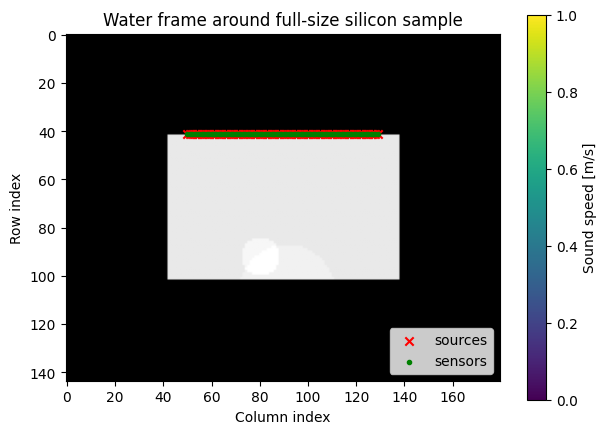

dt = 1.098e-10 s
Total simulation time = 0.329 µs


In [67]:
# Settings
scale_factor = 50

# Original silicon sample size
# This remains 640 µm × 480 µm because dx = 5 µm
#sample_N = (128, 96)
sample_N = (60, 96)
dx = (5e-6, 5e-6)

# Water frame thickness around all faces of the sample
# About 1/3 of the sample height: 128 / 3 ≈ 42 cells
#water_cells = sample_N[0] // 3

water_cells = 42
# Full simulation domain = water frame + original silicon sample
N = (
    sample_N[0] + 2 * water_cells,
    sample_N[1] + 2 * water_cells,
)

cfl = 0.2
num_sources = 80
source_freq = 1e6 * 1 * scale_factor
# source_mag = 1.3e-5
source_mag = 800.0

random_seed = random.PRNGKey(42)

# Define domain
domain = Domain(N, dx)


# ============================================================
# Define medium: water frame around full-size silicon sample
# ============================================================

water_speed = 1480.0   # m/s, approximate speed of sound in water
si_speed = 8433.0      # m/s, silicon-like speed from your original code

# Silicon sample location inside the larger water domain
sample_top = water_cells
sample_left = water_cells
sample_bottom = sample_top + sample_N[0]
sample_right = sample_left + sample_N[1]

# Start with water everywhere
sound_speed = water_speed * jnp.ones(N)

# Create a silicon sample mask
# 0 = water
# 1 = silicon sample
sample_mask = jnp.zeros(N)
sample_mask = sample_mask.at[
    sample_top:sample_bottom,
    sample_left:sample_right
].set(1.0)

# Put silicon speed inside the sample region
sound_speed = sound_speed * (1.0 - sample_mask) + si_speed * sample_mask


# ============================================================
# Circular inclusions inside the silicon sample
# ============================================================
# Original circle centers were in the old sample coordinates:
# circle_1: (50, 38)
# circle_2: (82, 48)
# circle_3: (65, 49)
#
# Now the sample is shifted by:
# row shift = sample_top
# col shift = sample_left

circle_1 = circ_mask(N, 8,  (sample_top + 50, sample_left + 38)) * sample_mask
circle_2 = circ_mask(N, 10, (sample_top + 82, sample_left + 48)) * sample_mask
circle_3 = circ_mask(N, 20, (sample_top + 65, sample_left + 49)) * sample_mask

sound_speed = sound_speed + si_speed * (
    0.05 * circle_1 + 0.02 * circle_2 + 0.03 * circle_3
)

# Convert the sound-speed map into a j-wave FourierSeries field
sound_speed = FourierSeries(jnp.expand_dims(sound_speed, -1), domain)

medium = Medium(domain=domain, sound_speed=sound_speed, pml_size=8.0)


# ============================================================
# Time axis
# ============================================================

time_axis = TimeAxis.from_medium(medium, cfl=cfl)

# Force a long time window, as in your reference figure
n_steps = 3000
time_axis = TimeAxis(dt=time_axis.dt, t_end=n_steps * time_axis.dt)
t = time_axis.to_array()


# ============================================================
# Source signal
# ============================================================

s1 = source_mag * jnp.sin(2 * jnp.pi * source_freq * t)

# Pulse position to avoid shift
center_index = 200
center_time = center_index * time_axis.dt

# Gaussian pulse width
#sigma_time = 24e-9
sigma_time = 12e-9

signal = gaussian_window(
    apply_ramp(s1, time_axis.dt, source_freq),
    t,
    center_time,
    sigma_time
)


# ============================================================
# Sources and sensors directly at the sample surface
# ============================================================

num_sensors = num_sources  # 80 sensors because num_sources = 80

# The silicon sample starts at row sample_top.
# sample_top - 1 is the last water row before the silicon.
# This places the sources and sensors directly above the sample surface,
# but still inside the surrounding water.
source_row = sample_top - 1
sensor_row = sample_top - 1

# Horizontally, place sources/sensors across the silicon sample width.
# We avoid the exact sample edges by using an 8-cell margin inside the sample width.
cols = jnp.linspace(
    sample_left + 8,
    sample_right - 9,
    num_sources
).round().astype(int)

source_positions = (
    jnp.full((num_sources,), source_row, dtype=int),
    cols,
)

sensors_positions = (
    jnp.full((num_sensors,), sensor_row, dtype=int),
    cols,
)

sensors = Sensors(positions=sensors_positions)


# ============================================================
# Optional: visualize the new setup
# ============================================================

plt.figure(figsize=(7, 5))
plt.imshow(medium.sound_speed.on_grid[..., 0], cmap="gray")
plt.scatter(
    source_positions[1],
    source_positions[0],
    c="r",
    marker="x",
    label="sources"
)
plt.scatter(
    sensors_positions[1],
    sensors_positions[0],
    c="g",
    marker=".",
    label="sensors"
)
plt.colorbar(label="Sound speed [m/s]")
plt.legend(loc="lower right")
plt.title("Water frame around full-size silicon sample")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()


total_time_us = n_steps * time_axis.dt * 1e6
print(f"dt = {time_axis.dt:.3e} s")
print(f"Total simulation time = {total_time_us:.3f} µs")


# ============================================================
# Optional: old circular source/sensor setup
# ============================================================

# x, y = points_on_circle(num_sources, 40, (64, 48))
# source_positions = (jnp.array(x), jnp.array(y))

# sensors_positions = (x, y)
# sensors = Sensors(positions=sensors_positions)

Text(0.5, 1.0, 'Source signals')

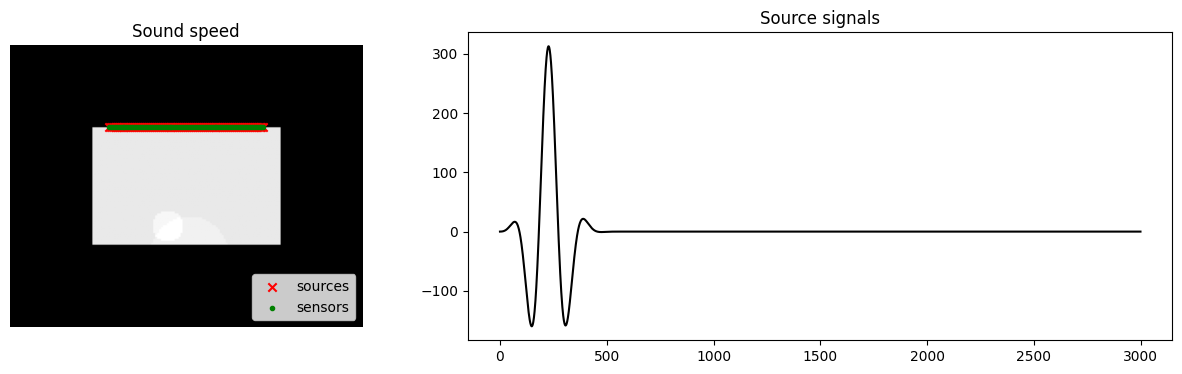

In [68]:
# Show simulation setup
fig, ax = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [1, 2]})

ax[0].imshow(medium.sound_speed.on_grid, cmap="gray")
ax[0].scatter(
    source_positions[1], source_positions[0], c="r", marker="x", label="sources"
)
ax[0].scatter(
    sensors_positions[1], sensors_positions[0], c="g", marker=".", label="sensors"
)
ax[0].legend(loc="lower right")
ax[0].set_title("Sound speed")
ax[0].axis("off")

ax[1].plot(signal, label="Source 1", c="k")
ax[1].set_title("Source signals")
#ax[1].get_yaxis().set_visible(False)

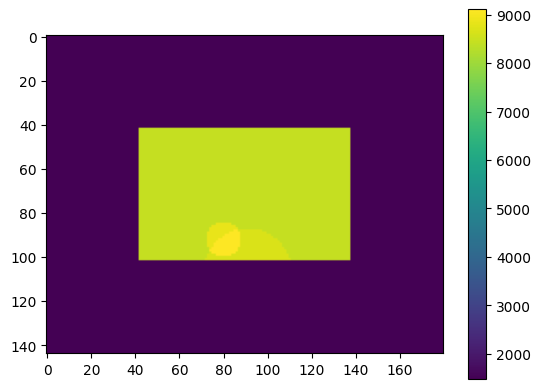

In [69]:
plt.imshow(medium.sound_speed.on_grid)
plt.colorbar()

In [70]:
src_signal = jnp.stack([signal])

# We can compile the entire function! All the constructors
# that don't depend on the inputs will be statically compiled
# and run only once.
@jit
def single_source_simulation(sound_speed, source_num):
    # Setting source
    x = lax.dynamic_slice(source_positions[0], (source_num,), (1,))
    y = lax.dynamic_slice(source_positions[1], (source_num,), (1,))
    sources = Sources((x, y), src_signal, dt=time_axis.dt, domain=domain)

    # Updating medium with the input speed of sound map
    medium = Medium(domain=domain, sound_speed=sound_speed, pml_size=8)

    # Run simulations
    # rf_signals = simulate_wave_propagation(
    #     medium, time_axis, sources=sources, sensors=sensors, checkpoint=True
    # )
    rf_signals = simulate_wave_propagation(
        medium, time_axis, sources=sources, sensors=sensors,
    )
    return rf_signals[..., 0]

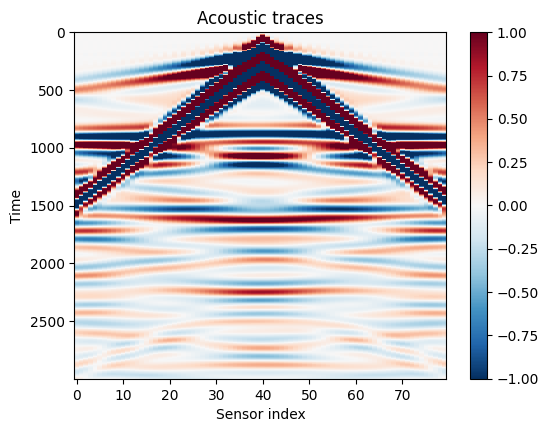

In [71]:

p = single_source_simulation(medium.sound_speed, 40)

# Visualize the acoustic traces
plt.figure(figsize=(6, 4.5))
maxval = jnp.amax(jnp.abs(p))
plt.imshow(
    p, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest", aspect="auto"
    
)
plt.colorbar()
plt.title("Acoustic traces")
plt.xlabel("Sensor index")
plt.ylabel("Time")
plt.show()

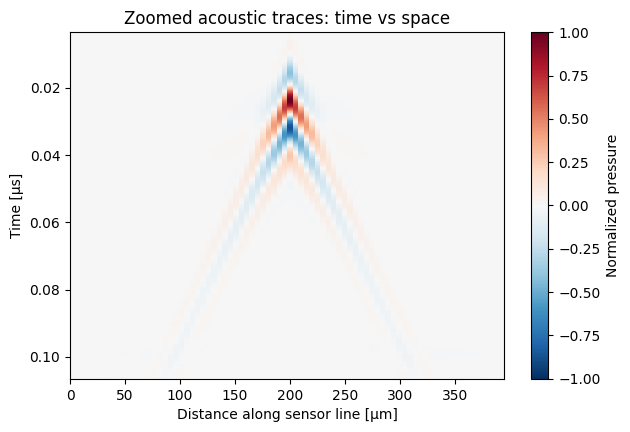

In [83]:
# ============================================================

# Prepare p

# ============================================================

p_np = np.array(p)

# Make sure shape is time × sensors

if p_np.shape[0] == num_sensors:

    p_np = p_np.T

n_time, n_sensors = p_np.shape

# Normalize

p_norm = p_np / np.nanmax(np.abs(p_np))

# Axes

time_us = np.arange(n_time) * float(time_axis.dt) * 1e6

sensor_cols = np.array(cols)

sensor_x_um = sensor_cols * dx[1] * 1e6

sensor_x_um = sensor_x_um - sensor_x_um[0]

# ============================================================

# Auto zoom to useful signal

# ============================================================

# Energy per time step

energy_t = np.max(np.abs(p_norm), axis=1)

# Find where signal is visible

zoom_threshold = 0.03

visible_idx = np.where(energy_t > zoom_threshold)[0]

if len(visible_idx) > 0:

    t0_idx = max(0, visible_idx[0] - 20)

    t1_idx = min(n_time - 1, visible_idx[-1] + 40)

else:

    t0_idx = 0

    t1_idx = n_time - 1

time_zoom_us = time_us[t0_idx:t1_idx + 1]

p_zoom = p_norm[t0_idx:t1_idx + 1, :]

# ============================================================

# Plot zoomed time-space diagram

# ============================================================

plt.figure(figsize=(7, 4.5))

plt.imshow(

    p_zoom,

    cmap="RdBu_r",

    vmin=-1,

    vmax=1,

    interpolation="nearest",

    aspect="auto",

    extent=[

        sensor_x_um[0],

        sensor_x_um[-1],

        time_zoom_us[-1],

        time_zoom_us[0],

    ],

)

plt.colorbar(label="Normalized pressure")

plt.title("Zoomed acoustic traces: time vs space")

plt.xlabel("Distance along sensor line [µm]")

plt.ylabel("Time [µs]")

plt.show()

In [84]:
# ============================================================
# First-arrival picking inside zoomed window
# ============================================================

arrival_threshold = 0.03

arrival_idx = np.full(n_sensors, np.nan)

for s in range(n_sensors):
    trace_abs = np.abs(p_norm[:, s])

    # Search only in the visible window
    segment = trace_abs[t0_idx:t1_idx + 1]
    hits = np.where(segment > arrival_threshold)[0]

    if len(hits) > 0:
        arrival_idx[s] = t0_idx + hits[0]

arrival_time_us = arrival_idx * float(time_axis.dt) * 1e6

# ============================================================
# Local speed calculation
# ============================================================

local_speed = np.full(n_sensors, np.nan)

for s in range(1, n_sensors):
    if not np.isnan(arrival_time_us[s]) and not np.isnan(arrival_time_us[s - 1]):
        dx_m_local = (sensor_x_um[s] - sensor_x_um[s - 1]) * 1e-6
        dt_s_local = (arrival_time_us[s] - arrival_time_us[s - 1]) * 1e-6

        if abs(dt_s_local) > 1e-15:
            local_speed[s] = abs(dx_m_local / dt_s_local)

arrival_table = pd.DataFrame({
    "sensor_index": np.arange(n_sensors),
    "x_position_um": sensor_x_um,
    "arrival_time_us": arrival_time_us,
    "local_apparent_speed_m_s": local_speed,
})

# Keep only sensors where an arrival was found
arrival_table_valid = arrival_table.dropna(subset=["arrival_time_us"]).reset_index(drop=True)

arrival_table_valid

,sensor_index,x_position_um,arrival_time_us,local_apparent_speed_m_s
0,18,90.0,0.100685,NaN
1,19,95.0,0.096952,1339.358741
2,20,100.0,0.093987,1686.599896
3,21,105.0,0.091022,1686.599896
4,22,110.0,0.087070,1264.949922
5,23,115.0,0.083117,1264.949922
6,24,120.0,0.072137,455.381972
7,25,125.0,0.068185,1264.949922
8,26,130.0,0.064451,1339.358741
9,27,135.0,0.060718,1339.358741


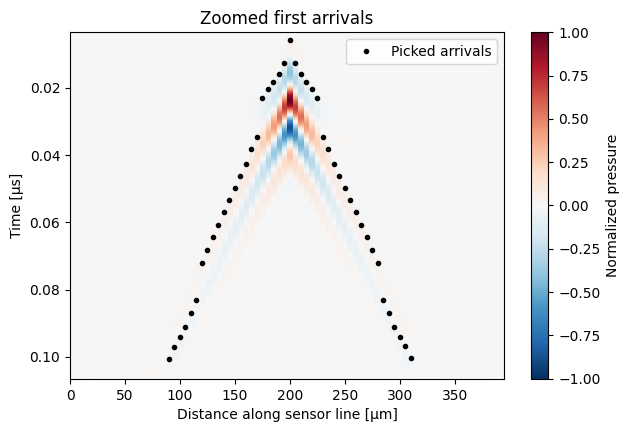

In [85]:
plt.figure(figsize=(7, 4.5))

plt.imshow(
    p_zoom,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    interpolation="nearest",
    aspect="auto",
    extent=[
        sensor_x_um[0],
        sensor_x_um[-1],
        time_zoom_us[-1],
        time_zoom_us[0],
    ],
)

valid = ~np.isnan(arrival_time_us)

plt.plot(
    sensor_x_um[valid],
    arrival_time_us[valid],
    "ko",
    markersize=3,
    label="Picked arrivals"
)

plt.colorbar(label="Normalized pressure")
plt.title("Zoomed first arrivals")
plt.xlabel("Distance along sensor line [µm]")
plt.ylabel("Time [µs]")
plt.legend()
plt.show()

In [86]:
source_index = 40

source_x_um = sensor_x_um[source_index]
distance_from_source_um = np.abs(sensor_x_um - source_x_um)

arrival_table_valid["distance_from_source_um"] = distance_from_source_um[
    arrival_table_valid["sensor_index"].values
]

arrival_table_valid = arrival_table_valid[
    [
        "sensor_index",
        "x_position_um",
        "distance_from_source_um",
        "arrival_time_us",
        "local_apparent_speed_m_s",
    ]
]

arrival_table_valid

,sensor_index,x_position_um,distance_from_source_um,arrival_time_us,local_apparent_speed_m_s
0,18,90.0,110.0,0.100685,NaN
1,19,95.0,105.0,0.096952,1339.358741
2,20,100.0,100.0,0.093987,1686.599896
3,21,105.0,95.0,0.091022,1686.599896
4,22,110.0,90.0,0.087070,1264.949922
5,23,115.0,85.0,0.083117,1264.949922
6,24,120.0,80.0,0.072137,455.381972
7,25,125.0,75.0,0.068185,1264.949922
8,26,130.0,70.0,0.064451,1339.358741
9,27,135.0,65.0,0.060718,1339.358741


In [34]:
%%timeit
single_source_simulation(medium.sound_speed, 1).block_until_ready()

3.45 s ± 10.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [52]:
batch_simulations = vmap(single_source_simulation, in_axes=(None, 0))
p_data = batch_simulations(medium.sound_speed, jnp.arange(num_sources))
print(f"Size of data [Source idx, Time, Sensor idx]: {p_data.shape}")

Size of data [Source idx, Time, Sensor idx]: (80, 3000, 80)


In [36]:
%%timeit
batch_simulations(medium.sound_speed, jnp.arange(num_sources)).block_until_ready()

4min 47s ± 1.84 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


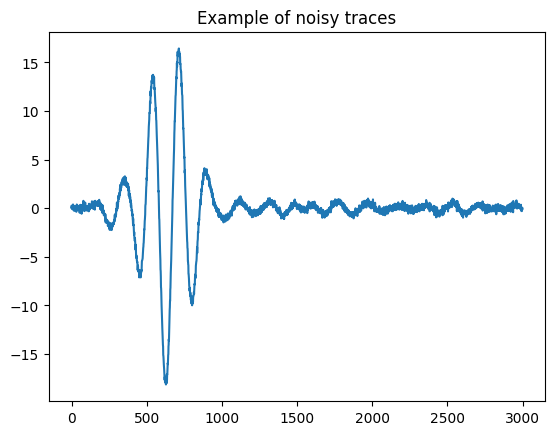

In [88]:
p_data = batch_simulations(medium.sound_speed, jnp.arange(num_sources))
noise = np.random.normal(size=p_data.shape) * 0.2
noise = jnp.fft.fft(noise, axis=1)
#noise = noise.at[:, 100:-100].set(0.0)
noise = jnp.fft.ifft(noise, axis=1).real
p_data = p_data + noise

plt.plot(p_data[12, :, 0])
plt.title("Example of noisy traces")
plt.show()

In [89]:
from jaxdf.operators import compose

mask_grid = jnp.zeros(N)


# Reconstruction region inside the wafer, below the source/sensor layer

#mask_grid = mask_grid.at[14:95, 8:88].set(1.0)


margin = 4

mask_grid = mask_grid.at[

    sample_top + margin : sample_bottom - margin,

    sample_left + margin : sample_right - margin

].set(1.0)



mask = FourierSeries(jnp.expand_dims(mask_grid, -1), domain)



# mask = circ_mask(domain.N, 40, (64, 48))
# mask = FourierSeries(jnp.expand_dims(mask, -1), domain)

def get_sound_speed(params):
    return 8433.0 + 850.0*compose(params)(nn.sigmoid) * mask

params = medium.sound_speed * 0.0 - 4

In [90]:
from jwave.signal_processing import analytic_signal
from jaxdf.operators import gradient, functional

def hilbert_transf(signal, noise=0.2):
    x = jnp.abs(analytic_signal(signal))
    return x

def loss_func(params, source_num):
    c0 = get_sound_speed(params)
    p = single_source_simulation(c0, source_num)
    data = p_data[source_num]
    return jnp.mean(jnp.abs(hilbert_transf(p) -hilbert_transf(data)) ** 2)

loss_with_grad = value_and_grad(loss_func, argnums=0)

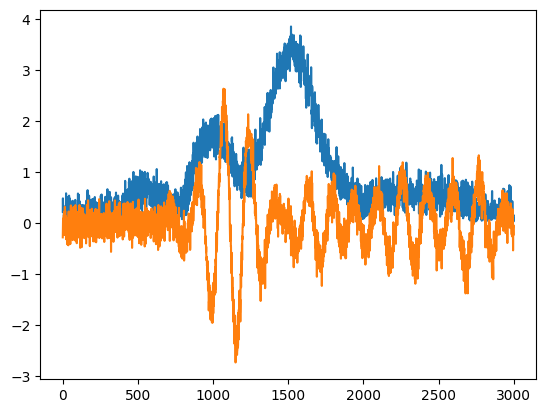

In [102]:
plt.plot(hilbert_transf(p_data[40, :, 0]))
plt.plot(p_data[80, :, 0])
plt.show()

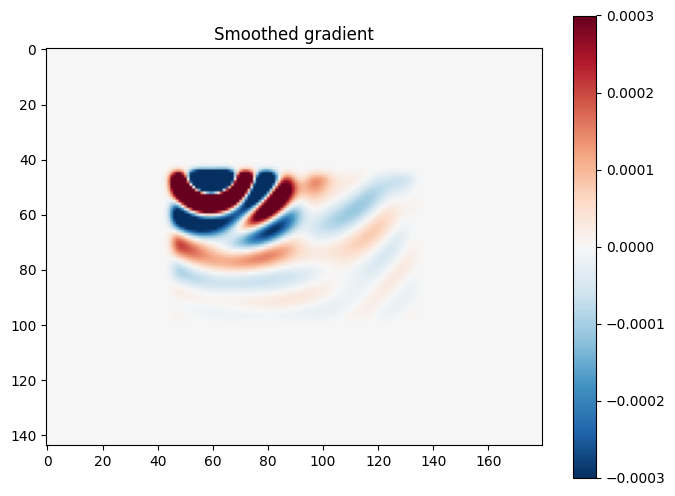

In [92]:
def smooth_fun(gradient):
    x = gradient.on_grid[..., 0]
    for _ in range(3):
        x = smooth(x)
    return gradient.replace_params(jnp.expand_dims(x, -1))*6

loss, gradient = loss_with_grad(params, source_num=10)
gradient = smooth_fun(gradient)

# Viualize
plt.figure(figsize=(8, 6))
plt.imshow(gradient.on_grid, cmap="RdBu_r", vmin=-0.0003, vmax=0.0003)
plt.title("Smoothed gradient")
plt.colorbar()
plt.show()

In [93]:


losshistory = []
reconstructions = []
num_steps = 100

# Define optimizer
init_fun, update_fun, get_params = optimizers.adam(0.1, 0.9, 0.9)
opt_state = init_fun(params)

# Define and compile the update function
@jit
def update(opt_state, key, k):
    v = get_params(opt_state)
    src_num = random.choice(key, num_sources)
    lossval, gradient = loss_with_grad(v, src_num)
    gradient = smooth_fun(gradient)
    return lossval, update_fun(k, gradient, opt_state)


# Main loop
pbar = tqdm(range(num_steps))
_, key = random.split(random_seed)
for k in pbar:
    _, key = random.split(key)
    lossval, opt_state = update(opt_state, key, k)

    ## For logging
    new_params = get_params(opt_state)
    reconstructions.append(get_sound_speed(new_params).on_grid)
    losshistory.append(lossval)
    pbar.set_description("Loss: {}".format(lossval))

Loss: 221.82496643066406: 100%|█████████████████████████████████████████| 100/100 [13:09<00:00,  7.89s/it]


In [94]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

/var/folders/s7/3v2vl8f51x7b9mhx69n0gt480000gn/T/ipykernel_11052/10384555.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


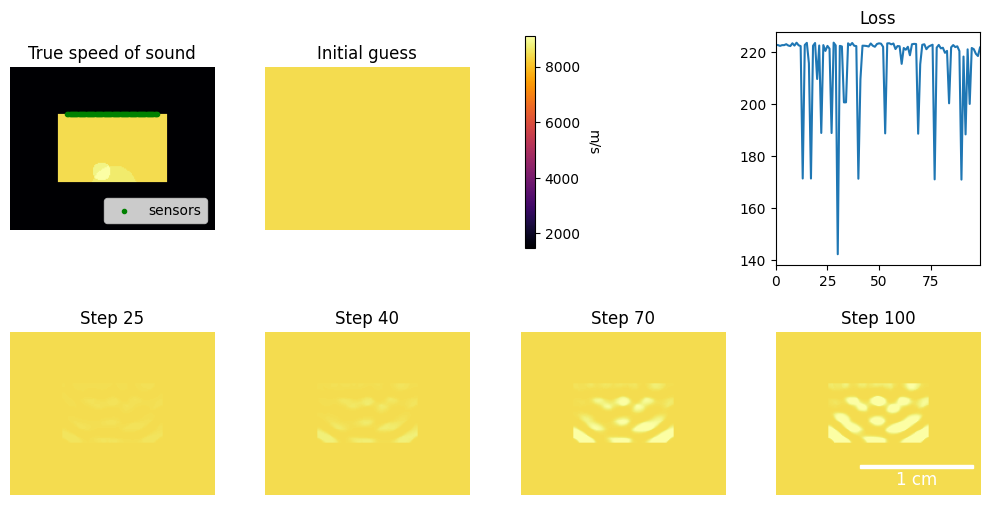

In [95]:
sos_original = get_sound_speed(params).on_grid
true_sos = sound_speed.on_grid
vmin = np.amin(true_sos)
vmax = np.amax(true_sos)

fig, axes = plt.subplots(2, 4, figsize=(10, 5.5))

k = 0
recs = [24, 39, 69, 99]
for row in range(2):
    for col in range(4):
        if k == 0:
            axes[row, col].imshow(true_sos, cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].scatter(
                sensors_positions[1],
                sensors_positions[0],
                c="g",
                marker=".",
                label="sensors",
            )
            axes[row, col].legend(loc="lower right")
            axes[row, col].set_title("True speed of sound")
            axes[row, col].set_axis_off()
        elif k == 1:
            im_original = axes[row, col].imshow(sos_original, cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].set_axis_off()
            axes[row, col].set_title("Initial guess")
            
            cbar_ax = fig.add_axes([0.53, 0.54, 0.01, 0.385])
            cbar = plt.colorbar(im_original, cax=cbar_ax)
            cbar.ax.get_yaxis().labelpad = 15
            cbar.ax.set_ylabel('m/s', rotation=270)
        elif k == 2:
            axes[row, col].set_axis_off()
        elif k == 3:
            axes[row, col].plot(losshistory)
            axes[row, col].set_title("Loss")
            #axes[row, col].set_xticks([], [])
            axes[row, col].margins(x=0)
        else:
            axes[row, col].imshow(reconstructions[recs[k - 4]], cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].set_axis_off()
            axes[row, col].set_title("Step {}".format(recs[k - 4] + 1))
        k += 1

# Scale bar
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(
    axes[-1, -1].transData,
    100, '1 cm', 'lower right', 
    pad=0.3,
    color='white',
    frameon=False,
    size_vertical=2,
    fontproperties=fontprops)
axes[-1, -1].add_artist(scalebar)
        
fig.tight_layout()

plt.savefig('fwi.pdf')